In [71]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_groq import ChatGroq
from dotenv import load_dotenv

In [72]:
load_dotenv()

True

In [73]:
model = ChatGroq(
    model='openai/gpt-oss-20b'
)

In [74]:
class BlogState(TypedDict):

    title: str
    outline: str
    content: str

In [75]:
def create_outline(state: BlogState) -> BlogState:
    #fetch_title
    title = state['title']

    #call llm and genarate outline
    prompt = f'Genarate a detailed outline for a blogon the topic - {title}'
    outline = model.invoke(prompt).content

    #update state
    state['outline'] = outline

    return state

In [76]:
def create_blog(state: BlogState) -> BlogState:
    #fetch_title and current outline
    title = state['title']
    outline = state['outline']

    #call llm and genarate outline
    prompt = f'Genarate a detailed blog from the title - {title} using the following outline \n{outline}'

    content = model.invoke(prompt).content

    #update state
    state['content'] = content

    return state

In [77]:
graph = StateGraph(BlogState)

graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog' )
graph.add_edge('create_blog', END)

In [78]:
workflow = graph.compile()

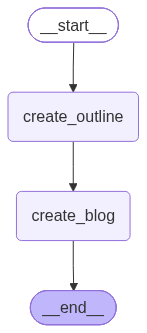

In [79]:
workflow

In [80]:
initial_state = {'title': 'Rise of AI in India'}

final_state = workflow.invoke(initial_state)

In [81]:
final_state

{'title': 'Rise of AI in India',
 'outline': '## Blog Outline: “Rise of AI in India”\n\n---\n\n### 1. Introduction  \n- **Hook**: A striking statistic or anecdote (e.g., “India’s AI market is projected to hit $5.4\u202fbn by 2025”).\n- **Thesis Statement**: A concise sentence outlining the blog’s purpose – to explore how AI is reshaping India across technology, economy, society, and governance.\n- **Road‑map**: Briefly list the main sections that will be covered.\n\n---\n\n### 2. Historical Context & Evolution  \n- **Early Beginnings**  \n  - 1990s: AI research in Indian Institutes of Technology (IITs) and Indian Institutes of Information Technology (IIITs).  \n  - 2000s: First AI startups (e.g., Wipro’s AI initiatives, Infosys Nia).  \n- **Milestones**  \n  - 2014: Government’s “National Strategy for Artificial Intelligence” (NSAI).  \n  - 2016‑2018: Rise of data‑centric startups (e.g., Haptik, Niki, Locus).  \n- **Current Landscape**  \n  - AI research labs (e.g., IIT Bombay’s Centre

In [82]:
print(final_state['outline'])

## Blog Outline: “Rise of AI in India”

---

### 1. Introduction  
- **Hook**: A striking statistic or anecdote (e.g., “India’s AI market is projected to hit $5.4 bn by 2025”).
- **Thesis Statement**: A concise sentence outlining the blog’s purpose – to explore how AI is reshaping India across technology, economy, society, and governance.
- **Road‑map**: Briefly list the main sections that will be covered.

---

### 2. Historical Context & Evolution  
- **Early Beginnings**  
  - 1990s: AI research in Indian Institutes of Technology (IITs) and Indian Institutes of Information Technology (IIITs).  
  - 2000s: First AI startups (e.g., Wipro’s AI initiatives, Infosys Nia).  
- **Milestones**  
  - 2014: Government’s “National Strategy for Artificial Intelligence” (NSAI).  
  - 2016‑2018: Rise of data‑centric startups (e.g., Haptik, Niki, Locus).  
- **Current Landscape**  
  - AI research labs (e.g., IIT Bombay’s Centre for Artificial Intelligence, Microsoft Research India).  
  - AI tale

In [83]:

print(final_state['content'])

# Rise of AI in India  
*From IIT labs to smart cities – how artificial intelligence is reshaping a nation of 1.4 billion people.*

---

## 1. Introduction  

> **Hook:** *India’s AI market is projected to hit $5.4 bn by 2025, up from just a few hundred million a decade ago.*  

Artificial Intelligence (AI) is no longer a niche research topic confined to a handful of labs. In India it has become a catalyst for economic growth, a driver of social change, and a strategic priority for the government.  

**Thesis Statement** – This blog explores how AI is reshaping India across technology, economy, society, and governance, and what that means for the future of the country.  

**Road‑map** – We’ll trace the historical evolution of AI in India, identify the key drivers of adoption, showcase sector‑specific success stories, unpack government initiatives, dive into the startup ecosystem, confront challenges and ethical concerns, and finally look ahead at the trends that will define the next de